# Java-fusion training

### Essential imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
#import torchvision
#from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import os

## Model construction

### Resnet block definition (key part of U-Net)

In [33]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_embed_dim):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_embed_dim, out_channels)
        )

        self.block1 = nn.Sequential(
            #nn.GroupNorm(8, in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, 3, padding=1)
        )

        self.block2 = nn.Sequential(
            #nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1)
        )

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, t, debug=False):
        h = self.block1(x)
        h += self.time_mlp(t)[:, :, None, None]
        h = self.block2(h)
        if (debug):
            #print("Inp: \n"+str(x[0,0])) 
            print("Out: \n"+str(h[0,0]))
            print("Plus 'identity: \n" + str((h + self.shortcut(x))[0,0]))
        return h + self.shortcut(x)

### Timestep embedding (not related to Noise scheduler)

In [3]:
def timestep_embedding(timesteps, dim, max_period=10000):
    """Sinusoidal timestep embeddings"""
    half = dim // 2
    freqs = torch.exp(
        -math.log(max_period) * torch.arange(start=0, end=half, dtype=torch.float32) / half
    ).to(device=timesteps.device)
    args = timesteps[:, None].float() * freqs[None]
    embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2:
        embedding = torch.cat([embedding, torch.zeros_like(embedding[:, :1])], dim=-1)
    return embedding

### Model architecture definition

In [65]:
# =================== SIMPLE U-NET ===================
class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, model_channels=64, out_channels=3, num_res_blocks=2):
        super().__init__()

        self.time_embed_dim = model_channels * 4

        # Time embedding
        self.time_embed = nn.Sequential(
            nn.Linear(model_channels, self.time_embed_dim),
            nn.SiLU(),
            nn.Linear(self.time_embed_dim, self.time_embed_dim),
        )

        # Encoder
        self.conv_in = nn.Conv2d(in_channels, model_channels, 3, padding=1)

        # Encoder - Fixed channel progression
        self.down1 = nn.ModuleList([
            ResBlock(model_channels, model_channels, self.time_embed_dim),      # 64->64
            ResBlock(model_channels, model_channels, self.time_embed_dim),      # 64->64
            nn.Conv2d(model_channels, model_channels * 2, 3, stride=2, padding=1)  # 64->128
        ])

        self.down2 = nn.ModuleList([
            ResBlock(model_channels * 2, model_channels * 2, self.time_embed_dim),  # 128->128
            ResBlock(model_channels * 2, model_channels * 4, self.time_embed_dim),  # 128->256
            nn.Conv2d(model_channels * 4, model_channels * 4, 3, stride=2, padding=1)  # 256->256
        ])

        # Middle - operates on 256 channels
        self.middle = nn.ModuleList([
            ResBlock(model_channels * 4, model_channels * 4, self.time_embed_dim),  # 256->256
            ResBlock(model_channels * 4, model_channels * 4, self.time_embed_dim),  # 256->256
        ])

        # Decoder - Fixed to handle concatenations properly
        self.up1 = nn.ModuleList([
            nn.ConvTranspose2d(model_channels * 4, model_channels * 4, 4, stride=2, padding=1),  # 256->256, upsample
            ResBlock(model_channels * 4 + model_channels * 4, model_channels * 2, self.time_embed_dim),  # 512->128 (concat+reduce)
            ResBlock(model_channels * 2 + model_channels * 2, model_channels * 2, self.time_embed_dim),  # 256->128 (concat+keep)
        ])

        self.up2 = nn.ModuleList([
            nn.ConvTranspose2d(model_channels * 2, model_channels * 2, 4, stride=2, padding=1),  # 128->128, upsample
            ResBlock(model_channels * 2 + model_channels, model_channels, self.time_embed_dim),      # 192->64 (concat+reduce)
            ResBlock(model_channels + model_channels, model_channels, self.time_embed_dim),          # 128->64 (concat+reduce)
        ])

        self.conv_out = nn.Sequential(
            #nn.GroupNorm(8, model_channels),
            nn.SiLU(),
            nn.Conv2d(model_channels, out_channels, 3, padding=1)
        )

    def forward(self, x, timesteps):
        # Time embedding
        t = self.time_embed(timestep_embedding(timesteps, dim=64))

        # Encoder
        h = self.conv_in(x)  # 3->64
        hs = []

        # Down1: 64->64->64, then downsample to 128
        h = self.down1[0](h, t, False)  # ResBlock: 64->64
        hs.append(h)
        h = self.down1[1](h, t)  # ResBlock: 64->64
        hs.append(h)
        h = self.down1[2](h)     # Downsample: 64->128

        # Down2: 128->128->256, then downsample to 256
        h = self.down2[0](h, t)  # ResBlock: 128->128
        hs.append(h)
        h = self.down2[1](h, t)  # ResBlock: 128->256
        hs.append(h)
        h = self.down2[2](h)     # Downsample: 256->256

        # Middle: 256->256->256
        h = self.middle[0](h, t)
        h = self.middle[1](h, t)

        # Decoder - carefully match the skip connections
        # Up1: 256 + skip connections
        h = self.up1[0](h)  # Upsample: 256->256
        h = torch.cat([h, hs.pop()], dim=1)  # 256+256=512
        h = self.up1[1](h, t)  # ResBlock: 512->128
        h = torch.cat([h, hs.pop()], dim=1)  # 128+128=256
        h = self.up1[2](h, t)  # ResBlock: 256->128

        # Up2: 128 + skip connections
        h = self.up2[0](h)  # Upsample: 128->128
        h = torch.cat([h, hs.pop()], dim=1)  # 128+64=192
        h = self.up2[1](h, t)  # ResBlock: 192->64
        #print(h[0,26])
        h = torch.cat([h, hs.pop()], dim=1)  # 64+64=128
        h = self.up2[2](h, t)  # ResBlock: 128->64

        return self.conv_out(h)

## DDPM framework

### Noise scheduler

In [5]:
# =================== NOISE SCHEDULE ===================
def linear_beta_schedule(timesteps, beta_start=0.0001, beta_end=0.02):
    """Simple linear noise schedule - most reliable"""
    return torch.linspace(beta_start, beta_end, timesteps)

### Main DDPM class (where all comes together)

In [6]:
# =================== DDPM CLASS ===================
class SimpleDDPM:
    def __init__(self, model, timesteps=2500, device="cuda"):
        self.model = model.to(device)
        self.timesteps = timesteps
        self.device = device

        # Noise schedule
        self.betas = linear_beta_schedule(timesteps).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)

        # Pre-compute values for sampling
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

    def q_sample(self, x_start, t, noise=None):
        """Add noise to images (forward process)"""
        if noise is None:
            noise = torch.randn_like(x_start)

        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]

        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

    def train_step(self, batch):
        """Single training step"""
        x_start = batch.to(self.device)
        batch_size = x_start.shape[0]

        # Sample random timesteps
        t = torch.randint(0, self.timesteps, (batch_size,), device=self.device).long()

        # Add noise
        noise = torch.randn_like(x_start)
        x_noisy = self.q_sample(x_start, t, noise)

        # Predict noise
        predicted_noise = self.model(x_noisy, t)

        # Calculate loss
        loss = F.mse_loss(predicted_noise, noise)
        return loss

    @torch.no_grad()
    def sample(self, shape):
        """Generate samples"""
        device = self.device
        b = shape[0]
        img = torch.randn(shape, device=device)

        for i in tqdm(reversed(range(0, self.timesteps)), desc='Sampling'):
            t = torch.full((b,), i, device=device, dtype=torch.long)

            # Predict noise
            predicted_noise = self.model(img, t)

            # Compute coefficients
            alpha = self.alphas[i]
            alpha_cumprod = self.alphas_cumprod[i]
            beta = self.betas[i]

            # Update image
            img = (1 / torch.sqrt(alpha)) * (img - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod)) * predicted_noise)

            if i > 0:
                noise = torch.randn_like(img)
                img += torch.sqrt(beta) * noise

        return img

## Training and inference

### Dataset loading

In [ ]:
# =================== TRAINING SETUP ===================
def get_cifar10_dataloader(batch_size=32, class_idx=6):  # 6 = frogs
    """Load CIFAR-10 dataset filtered to single class"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Scale to [-1, 1]
    ])

    dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform
    )

    # Filter to only the desired class
    indices = [i for i, (_, label) in enumerate(dataset) if label == class_idx]
    subset = torch.utils.data.Subset(dataset, indices)

    print(f"Training on {len(indices)} samples from class {class_idx} (ships)")

    return DataLoader(subset, batch_size=batch_size, shuffle=True, num_workers=2)

def get_mnist_dataloader(batch_size=32, digit:int=None):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Single channel normalization
    ])

    dataset = torchvision.datasets.MNIST(
        root='./data', train=True, download=True, transform=transform
    )

    if digit:
      # Filter to only the desired digit
      indices = [i for i, (_, label) in enumerate(dataset) if label == digit]
      subset = torch.utils.data.Subset(dataset, indices)

      print(f"Training on {len(indices)} samples of digit {digit}")

    if digit:
      return DataLoader(subset, batch_size=batch_size, shuffle=True, num_workers=2)

    return DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

def show_samples(samples):
    """Display generated samples"""
    samples = (samples + 1) / 2  # Convert from [-1, 1] to [0, 1]
    samples = torch.clamp(samples, 0, 1)

    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    for i in range(4):
        img = samples[i].cpu().permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].axis('off')
    plt.show()

### Training loop

In [ ]:
def train_ddpm(epochs=10, dataset="cifar-10", digit=None):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Setup
    if dataset == "cifar-10":
      model = SimpleUNet()
      dataloader = get_cifar10_dataloader(batch_size=32, class_idx=8)  # ships
    elif dataset == "mnist":
      model = SimpleUNet(in_channels=1, out_channels=1)
      dataloader = get_mnist_dataloader(batch_size=32, digit=None)

    ddpm = SimpleDDPM(model, timesteps=2500, device=device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  # Lower initial LR

    # Add learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)


    # Training loop
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        progress_bar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}')

        for batch, _ in progress_bar:
            optimizer.zero_grad()
            loss = ddpm.train_step(batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            progress_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'lr': f'{scheduler.get_last_lr()[0]:.6f}'
            })

        # Step the scheduler after each epoch
        scheduler.step()

        avg_loss = total_loss / len(dataloader)
        print(f'Epoch {epoch+1} - Average Loss: {avg_loss:.4f} - LR: {scheduler.get_last_lr()[0]:.6f}')

        # Generate samples every 5 epochs
        if (epoch + 1) % 5 == 0:
            model.eval()
            if dataset=="cifar-10":
              samples = ddpm.sample((4, 3, 32, 32))
            elif dataset=="mnist":
              samples = ddpm.sample((4, 1, 28, 28))
            show_samples(samples)
            model.train()

    return ddpm

Using device: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.00MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 56.8kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.02MB/s]
Epoch 1/50: 100%|██████████| 1875/1875 [02:00<00:00, 15.52it/s, loss=0.0247, lr=0.000100]


Epoch 1 - Average Loss: 0.0309 - LR: 0.000100


Epoch 2/50: 100%|██████████| 1875/1875 [02:01<00:00, 15.37it/s, loss=0.0150, lr=0.000100]


Epoch 2 - Average Loss: 0.0178 - LR: 0.000100


...

Epoch 4/50: 100%|██████████| 1875/1875 [02:01<00:00, 15.44it/s, loss=0.0086, lr=0.000099]


Epoch 4 - Average Loss: 0.0157 - LR: 0.000098


Epoch 5/50: 100%|██████████| 1875/1875 [02:01<00:00, 15.44it/s, loss=0.0073, lr=0.000098]


Epoch 5 - Average Loss: 0.0155 - LR: 0.000098


Sampling: 2500it [00:17, 145.17it/s]


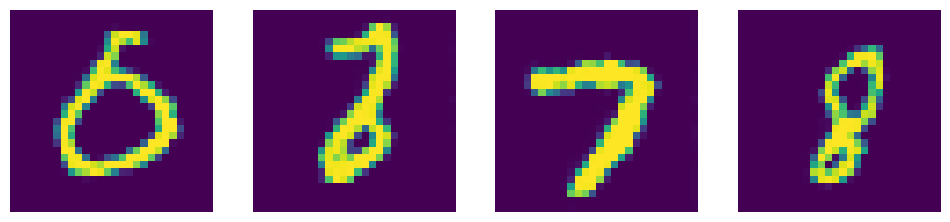

Epoch 6/50: 100%|██████████| 1875/1875 [02:01<00:00, 15.44it/s, loss=0.0165, lr=0.000098]


Epoch 6 - Average Loss: 0.0151 - LR: 0.000096


Epoch 7/50: 100%|██████████| 1875/1875 [02:01<00:00, 15.46it/s, loss=0.0072, lr=0.000096]


Epoch 7 - Average Loss: 0.0148 - LR: 0.000095


Epoch 8/50: 100%|██████████| 1875/1875 [02:01<00:00, 15.46it/s, loss=0.0242, lr=0.000095]


...

Epoch 9/50: 100%|██████████| 1875/1875 [02:01<00:00, 15.46it/s, loss=0.0087, lr=0.000094]


Epoch 9 - Average Loss: 0.0146 - LR: 0.000092


Epoch 10/50: 100%|██████████| 1875/1875 [02:01<00:00, 15.45it/s, loss=0.0115, lr=0.000092]


Epoch 10 - Average Loss: 0.0145 - LR: 0.000090


Sampling: 2500it [00:16, 149.76it/s]


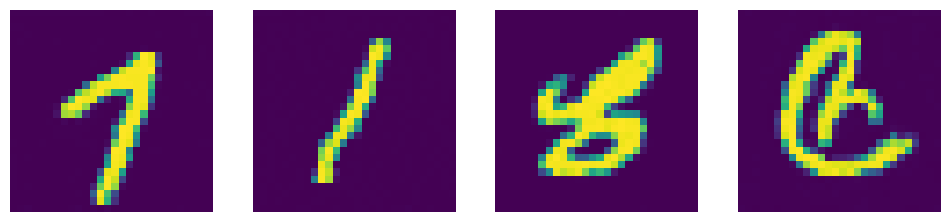

Epoch 11/50: 100%|██████████| 1875/1875 [02:01<00:00, 15.44it/s, loss=0.0106, lr=0.000090]


Epoch 11 - Average Loss: 0.0140 - LR: 0.000089


Epoch 12/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.26it/s, loss=0.0235, lr=0.000089]


Epoch 12 - Average Loss: 0.0144 - LR: 0.000086


Epoch 13/50: 100%|██████████| 1875/1875 [02:01<00:00, 15.39it/s, loss=0.0183, lr=0.000086]


...

Epoch 14/50: 100%|██████████| 1875/1875 [02:01<00:00, 15.39it/s, loss=0.0201, lr=0.000084]


Epoch 14 - Average Loss: 0.0138 - LR: 0.000082


Epoch 15/50: 100%|██████████| 1875/1875 [02:01<00:00, 15.39it/s, loss=0.0163, lr=0.000082]


Epoch 15 - Average Loss: 0.0140 - LR: 0.000079


Sampling: 2500it [00:16, 150.20it/s]


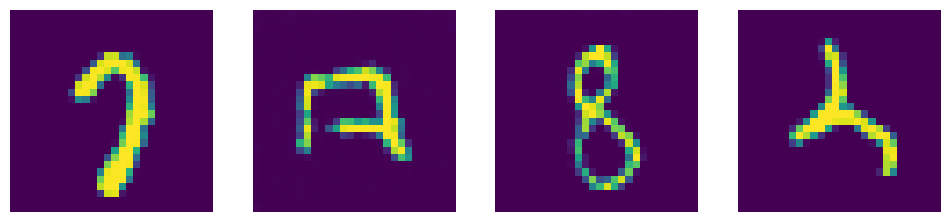

Epoch 16/50: 100%|██████████| 1875/1875 [02:01<00:00, 15.39it/s, loss=0.0093, lr=0.000079]


Epoch 16 - Average Loss: 0.0137 - LR: 0.000077


Epoch 17/50: 100%|██████████| 1875/1875 [02:01<00:00, 15.38it/s, loss=0.0157, lr=0.000077]


Epoch 17 - Average Loss: 0.0138 - LR: 0.000074


Epoch 18/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.28it/s, loss=0.0125, lr=0.000074]


...

Epoch 19/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.30it/s, loss=0.0119, lr=0.000071]


Epoch 19 - Average Loss: 0.0137 - LR: 0.000068


Epoch 20/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.25it/s, loss=0.0137, lr=0.000068]


Epoch 20 - Average Loss: 0.0133 - LR: 0.000065


Sampling: 2500it [00:17, 146.55it/s]


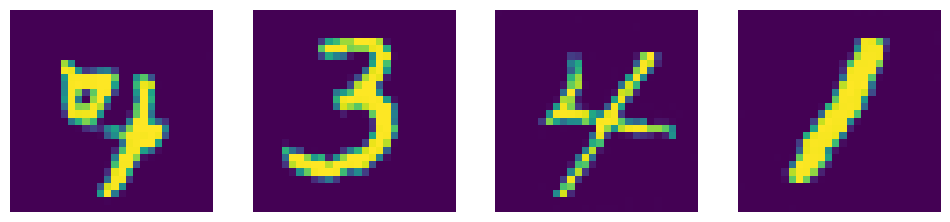

Epoch 21/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.31it/s, loss=0.0164, lr=0.000065]


Epoch 21 - Average Loss: 0.0134 - LR: 0.000062


Epoch 22/50: 100%|██████████| 1875/1875 [02:03<00:00, 15.24it/s, loss=0.0176, lr=0.000062]


Epoch 22 - Average Loss: 0.0136 - LR: 0.000059


Epoch 23/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.34it/s, loss=0.0222, lr=0.000059]


...

Epoch 24/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.28it/s, loss=0.0187, lr=0.000056]


Epoch 24 - Average Loss: 0.0134 - LR: 0.000053


Epoch 25/50: 100%|██████████| 1875/1875 [02:01<00:00, 15.37it/s, loss=0.0079, lr=0.000053]


Epoch 25 - Average Loss: 0.0133 - LR: 0.000050


Sampling: 2500it [00:16, 148.54it/s]


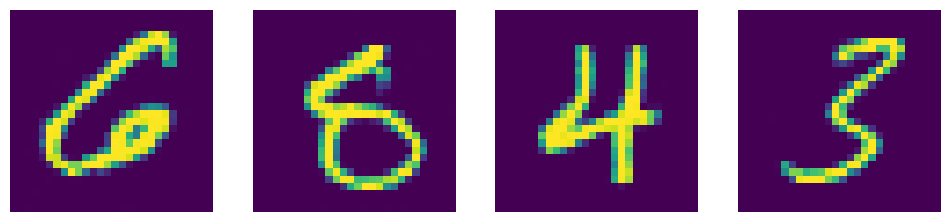

Epoch 26/50: 100%|██████████| 1875/1875 [02:03<00:00, 15.24it/s, loss=0.0122, lr=0.000050]


Epoch 26 - Average Loss: 0.0131 - LR: 0.000047


Epoch 27/50: 100%|██████████| 1875/1875 [02:03<00:00, 15.18it/s, loss=0.0121, lr=0.000047]


Epoch 27 - Average Loss: 0.0131 - LR: 0.000044


Epoch 28/50: 100%|██████████| 1875/1875 [02:03<00:00, 15.19it/s, loss=0.0184, lr=0.000044]


...

Epoch 29/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.25it/s, loss=0.0112, lr=0.000041]


Epoch 29 - Average Loss: 0.0130 - LR: 0.000038


Epoch 30/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.29it/s, loss=0.0192, lr=0.000038]


Epoch 30 - Average Loss: 0.0133 - LR: 0.000035


Sampling: 2500it [00:16, 148.15it/s]


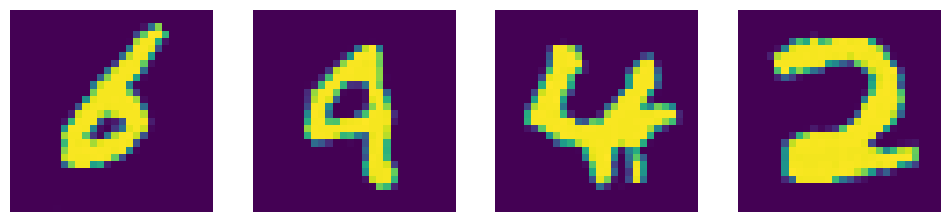

Epoch 31/50: 100%|██████████| 1875/1875 [02:03<00:00, 15.21it/s, loss=0.0161, lr=0.000035]


Epoch 31 - Average Loss: 0.0130 - LR: 0.000032


Epoch 32/50: 100%|██████████| 1875/1875 [02:03<00:00, 15.14it/s, loss=0.0109, lr=0.000032]


Epoch 32 - Average Loss: 0.0131 - LR: 0.000029


Epoch 33/50: 100%|██████████| 1875/1875 [02:03<00:00, 15.16it/s, loss=0.0187, lr=0.000029]


...

Epoch 34/50: 100%|██████████| 1875/1875 [02:03<00:00, 15.15it/s, loss=0.0084, lr=0.000026]


Epoch 34 - Average Loss: 0.0132 - LR: 0.000023


Epoch 35/50: 100%|██████████| 1875/1875 [02:03<00:00, 15.19it/s, loss=0.0160, lr=0.000023]


Epoch 35 - Average Loss: 0.0130 - LR: 0.000021


Sampling: 2500it [00:17, 146.21it/s]


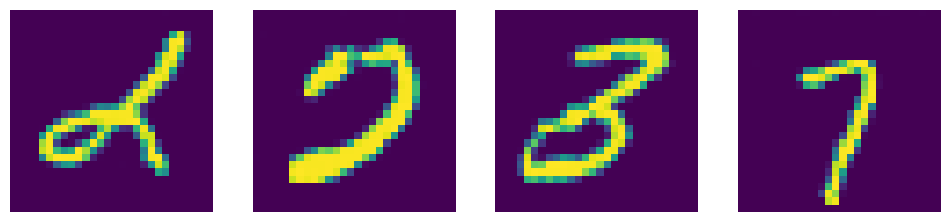

Epoch 36/50: 100%|██████████| 1875/1875 [02:03<00:00, 15.16it/s, loss=0.0042, lr=0.000021]


Epoch 36 - Average Loss: 0.0128 - LR: 0.000018


Epoch 37/50: 100%|██████████| 1875/1875 [02:03<00:00, 15.21it/s, loss=0.0058, lr=0.000018]


Epoch 37 - Average Loss: 0.0129 - LR: 0.000016


Epoch 38/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.31it/s, loss=0.0162, lr=0.000016]


...

Epoch 39/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.34it/s, loss=0.0142, lr=0.000014]


Epoch 39 - Average Loss: 0.0127 - LR: 0.000011


Epoch 40/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.31it/s, loss=0.0098, lr=0.000011]


Epoch 40 - Average Loss: 0.0128 - LR: 0.000010


Sampling: 2500it [00:16, 150.73it/s]


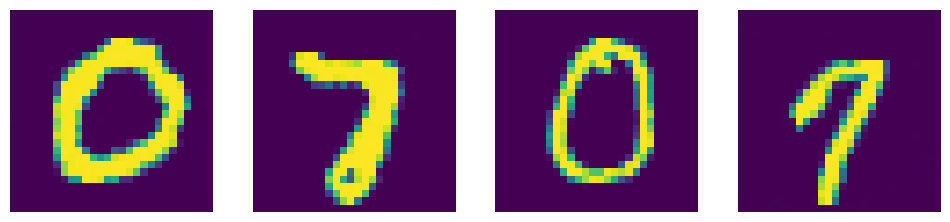

Epoch 41/50: 100%|██████████| 1875/1875 [02:03<00:00, 15.15it/s, loss=0.0080, lr=0.000010]


Epoch 41 - Average Loss: 0.0129 - LR: 0.000008


Epoch 42/50: 100%|██████████| 1875/1875 [02:04<00:00, 15.11it/s, loss=0.0144, lr=0.000008]


Epoch 42 - Average Loss: 0.0127 - LR: 0.000006


Epoch 43/50: 100%|██████████| 1875/1875 [02:03<00:00, 15.23it/s, loss=0.0139, lr=0.000006]


...

Epoch 44/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.34it/s, loss=0.0197, lr=0.000005]


Epoch 44 - Average Loss: 0.0128 - LR: 0.000004


Epoch 45/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.30it/s, loss=0.0108, lr=0.000004]


Epoch 45 - Average Loss: 0.0127 - LR: 0.000002


Sampling: 2500it [00:16, 152.36it/s]


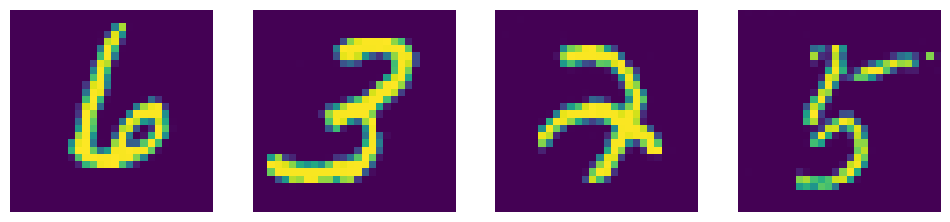

Epoch 46/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.31it/s, loss=0.0151, lr=0.000002]


Epoch 46 - Average Loss: 0.0128 - LR: 0.000002


Epoch 47/50: 100%|██████████| 1875/1875 [02:03<00:00, 15.24it/s, loss=0.0098, lr=0.000002]


Epoch 47 - Average Loss: 0.0124 - LR: 0.000001


Epoch 48/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.29it/s, loss=0.0157, lr=0.000001]


...

Epoch 49/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.28it/s, loss=0.0039, lr=0.000000]


Epoch 49 - Average Loss: 0.0127 - LR: 0.000000


Epoch 50/50: 100%|██████████| 1875/1875 [02:02<00:00, 15.26it/s, loss=0.0080, lr=0.000000]


Epoch 50 - Average Loss: 0.0126 - LR: 0.000000


Sampling: 2500it [00:16, 150.55it/s]


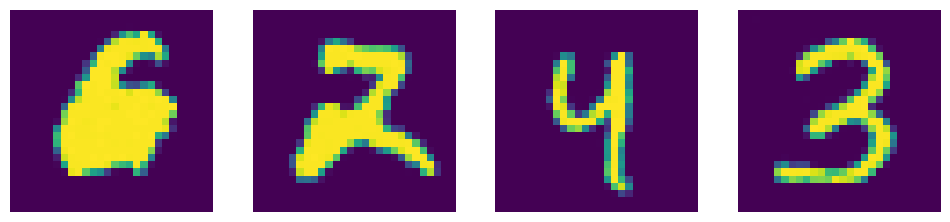

In [ ]:
# Train the model
ddpm_mnist = train_ddpm(epochs=50, dataset="mnist")

### Inference

Sampling: 2500it [00:26, 93.90it/s] 


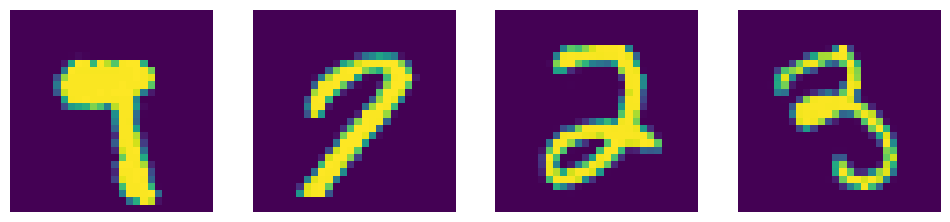

In [ ]:
# Generate final samples
ddpm_mnist.model.eval()
samples = ddpm_mnist.sample((8, 1, 28, 28))
show_samples(samples)

In [ ]:
sum(p.numel() for p in ddpm_mnist.model.parameters() if p.requires_grad)

7706561

## Saving and loading!

### Save model

In [ ]:
# Save the current trained model
torch.save({
    'model_state_dict': ddpm_mnist.model.state_dict(),
    'timesteps': ddpm_mnist.timesteps,
    'epoch': 50,  # or however many epochs you trained
}, 'ddpm_mnist_model.pth')

print("Model saved!")

Model saved!


### Load model

In [66]:
# Sample model loading
def load_trained_model(filepath='ddpm_fast_mnist_model.pth'):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Create model architecture
    model = SimpleUNet(in_channels=1, out_channels=1)
    ddpm = SimpleDDPM(model, timesteps=1000, device=device)
    
    # Load saved weights
    checkpoint = torch.load(filepath, map_location=device)
    ddpm.model.load_state_dict(checkpoint['model_state_dict'])
    
    print(f"Model loaded from {filepath}")
    return ddpm

# Usage:
loaded_ddpm = load_trained_model()
#samples = loaded_ddpm.sample((1, 1, 28, 28))
#show_samples(samples)
loaded_ddpm.model(torch.from_numpy(np.full((1,1,28,28), 2, dtype=np.float32)), torch.from_numpy(np.array([1])))

Model loaded from ddpm_fast_mnist_model.pth


tensor([[[[ 3.2700e+00,  6.5322e+00,  4.6077e+00,  3.4118e+00,  3.7583e+00,
            3.8229e+00,  4.1258e+00,  3.9181e+00,  4.0711e+00,  3.8412e+00,
            4.0428e+00,  3.8943e+00,  4.0577e+00,  3.8499e+00,  4.0200e+00,
            3.8991e+00,  4.0534e+00,  3.8511e+00,  4.0407e+00,  3.9581e+00,
            4.1929e+00,  3.9686e+00,  4.0331e+00,  3.5612e+00,  3.6884e+00,
            4.6066e+00,  4.7114e+00,  6.9273e-01],
          [ 3.8911e+00,  1.3478e+01,  1.1007e+01,  9.4120e+00,  1.0158e+01,
            1.0113e+01,  1.0387e+01,  1.0080e+01,  1.0279e+01,  1.0014e+01,
            1.0146e+01,  1.0008e+01,  1.0200e+01,  9.9810e+00,  1.0081e+01,
            9.9912e+00,  1.0187e+01,  9.9848e+00,  1.0096e+01,  1.0110e+01,
            1.0472e+01,  1.0362e+01,  1.0211e+01,  9.8941e+00,  9.9838e+00,
            1.1678e+01,  1.3316e+01, -7.9710e-03],
          [ 2.1451e+00,  1.0081e+01,  7.7870e+00,  7.2470e+00,  7.3580e+00,
            7.0701e+00,  7.4533e+00,  6.8186e+00,  7.3242e+00,

In [ ]:
# Load your model checkpoint
checkpoint = torch.load('ddpm_fast_mnist_model.pth', map_location='cpu')
state_dict = checkpoint.get('state_dict', checkpoint)

with open('layer_mapping.txt', 'w') as f:
    for key, tensor in state_dict['model_state_dict'].items():
        filename = 'weights/' + key.replace('.', '_') + '.npy'
        npy_array = tensor.cpu().numpy()
        np.save(filename, npy_array)

        shape_str = str(list(npy_array.shape))
        f.write(f"{key} -> {filename} (shape: {shape_str})\n")
